# Synthetic Generation using Diffusion with a Conditional
To see how a diffusion model canbe trained to create synthetic data, we generate a two dimensional dataset that has 8 disk like clusters around a circle centered at the origin. We will then train a diffusion to be able to generate synthetic data but use the labels and centers as a conditional

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from synthetic_generation.diffusion.models import DiffusionNet
from synthetic_generation.diffusion.process import DiffusionProcess
from synthetic_generation.diffusion.schedules import linear_beta_schedule

In [2]:
def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Parameters
    ----------
    n_samples : int
        number of samples
    centers : int 
        number of disk clusters
    radius : float
        radius of ring containing centers of the clusters
    std : float
        standard deviation for distance from center of disk for a point
    seed : int
        random seed to use
    Returns
    -------
    tuple
        array of sample points, array of cluster centers for each point, array of labels for each cluster
    """
    rng = np.random.default_rng(seed)
    # compute the centers of each cluster
    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    sample_labels = []
    sample_centers = []
    # choose a random center and a random point in the cluster
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        # add the center and label
        sample_labels.append(k)
        sample_centers.append(means[k])
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32), np.array(sample_labels), np.array(sample_centers,dtype=np.float32)

In [3]:
X_gauss, labels, centers = make_gaussian_mixture()

In [4]:
# make the conditional
one_hot_labels = F.one_hot(torch.tensor(labels)).float()
c = torch.cat([torch.Tensor(centers), one_hot_labels], dim=1)

#### Training the model
We create a simple DiffusionNet model and then use the DiffusionProcess with that model to train on the data along with the conditional

In [5]:
DenoiseNet = DiffusionNet(data_dim=2, conditional_dim=10, num_hidden_layers=4,  hidden_dims=(256,256))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoiseNet.to(device)

In [6]:
# turn the data into a tensor and move to device
X_train = torch.Tensor(X_gauss).to(device)
c=c.to(device)

In [7]:

diffusion_process = DiffusionProcess(
    model = model,
    num_timesteps = model.time_embedding.num_timesteps,
    betas=linear_beta_schedule(num_timesteps=model.time_embedding.num_timesteps)
)

In [8]:
diffusion_process.train(
    X=X_train,
    c=c
)

Diffusion training:   0%|          | 0/100 [00:00<?, ?it/s]

#### Visualization
We now create synthetic data from the process and look at a scatterplot to compare it to the real data.

In [9]:
sample_size = 10000
idx = np.random.default_rng(42).choice(len(X_gauss), size=sample_size, replace=False)
X_sample = X_gauss[idx]
c_sample = c[idx]

In [10]:
X_fake = diffusion_process.generate_samples(num_samples=sample_size, c=c_sample)

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Since we used a conditional, we'll color each point in the true and generated data based on the label

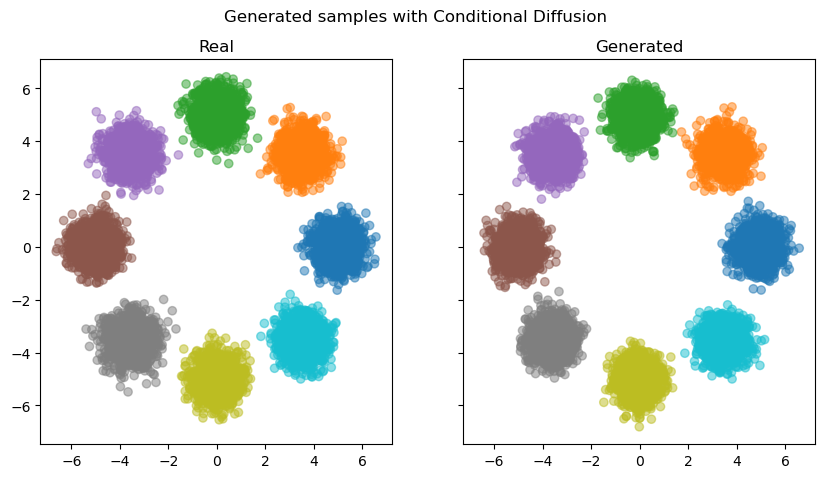

In [11]:
label_sample = labels[idx]
fig, axs = plt.subplots(1, 2, figsize = (10,5), sharex=True, sharey=True)
axs[0].scatter(X_sample[:, 0], X_sample[:, 1], alpha=0.5, c=label_sample, cmap='tab10')
axs[0].set_title("Real")
axs[1].scatter(X_fake[:, 0], X_fake[:, 1], alpha=0.5, c=label_sample, cmap='tab10')
axs[1].set_title("Generated")
fig.suptitle("Generated samples with Conditional Diffusion")
plt.show()

We can see that we get pretty decent coverage of the ring , and that the points generated correctly correspond to the label
Next, we try a faster version using DDIM with 50 inference steps.

In [12]:
X_fake_ddim = diffusion_process.generate_samples_ddim(
    num_samples=sample_size,
    c=c_sample,
    num_inference_steps=50,
    )

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

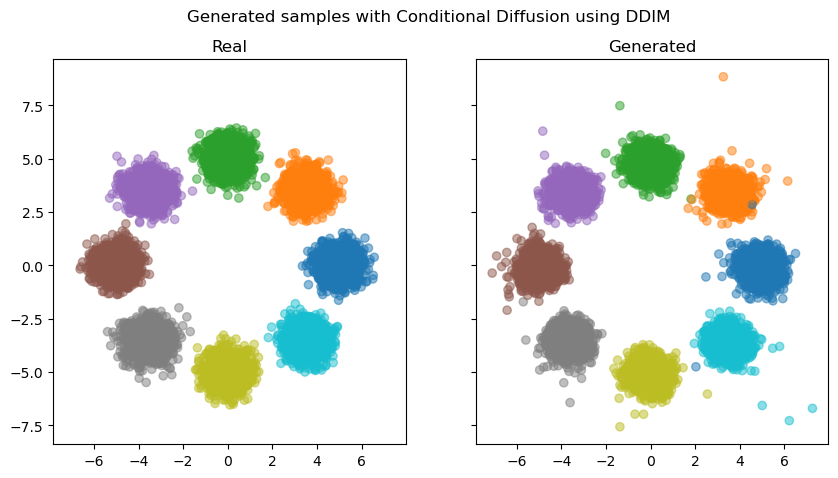

In [13]:
fig, axs = plt.subplots(1, 2, figsize = (10,5), sharex=True, sharey=True)
axs[0].scatter(X_sample[:, 0], X_sample[:, 1], alpha=0.5, c=label_sample, cmap='tab10')
axs[0].set_title("Real")
axs[1].scatter(X_fake_ddim[:, 0], X_fake_ddim[:, 1], alpha=0.5, c=label_sample, cmap='tab10')
axs[1].set_title("Generated")
fig.suptitle("Generated samples with Conditional Diffusion using DDIM")
plt.show()

We can see that DDIM here has a few issues , as we generated some outliers, so it is worse. The thing we're seeing is increased variance over each cluster.